In [61]:
from fiat_toolbox.well_being import (
    CapitalStock,
    IncomeStream,
    CommunityUnit,
    IncomeConfig,
    Liquidity,
    SimulationConfig,
    WellBeingConfig,
)

In [74]:
housing_assets = CapitalStock(v=0.7, k=300000, pi=0.15)
rental_assets = IncomeStream(v=0.4, income=20000, recovery_time=10)

public_assets = IncomeStream(v=0.3, income=70000, recovery_time=10)
private_assets = IncomeStream(v=0.25, income=60000, recovery_time=4)

income_config = IncomeConfig(i_avg=80000, i_div=20000)

sim_config = SimulationConfig(
    eta=1.5, rho=0.06, t_max=10, dt=1 / 52, currency="$", c_min=5000, recovery_per=95.0
)

liq = Liquidity(savings=0)

config = WellBeingConfig(
    owner_housing=housing_assets,
    labour_assets={"Public": public_assets, "Private": private_assets},
    rental_housing=rental_assets,
    income=income_config,
    simulation=sim_config,
    liquidity=liq,
)

In [75]:
# Create a WellBeing object and optimize the lambda value
household = CommunityUnit(config=config)
household

CommunityUnit(
  owner_housing = k=300000.0 v=0.7 recovery_time=None recovery_rate=None pi=0.15 recovery_label=None income_label=None,
  rental_housing = income=20000.0 v=0.4 recovery_time=10.0 recovery_rate=0.299573227355399 income_label=None,
  labour_assets = {'Public': IncomeStream(income=70000.0, v=0.3, recovery_time=10.0, recovery_rate=0.299573227355399, income_label=None), 'Private': IncomeStream(income=60000.0, v=0.25, recovery_time=4.0, recovery_rate=0.7489330683884975, income_label=None)},
  income = i_0=None i_avg=80000.0 i_div=20000.0 payments=None,
  liquidity = savings=0.0 insurance=0.0 support=0.0,
  simulation = eta=1.5 rho=0.06 t_max=10.0 dt=0.019230769230769232 currency='$' currency_decimals=0 c_min=5000.0 recovery_per=95.0
)

Status: boundary_lower
Success: True
Message: Minimum at lower λ bound (0.3 ≈ l_min), i.e. the slowest recovery / longest reconstruction time in the search range. Welfare may keep improving beyond this bound. Hint: widen the search (increase rec_time_max on CommunityUnit.opt_lambda).


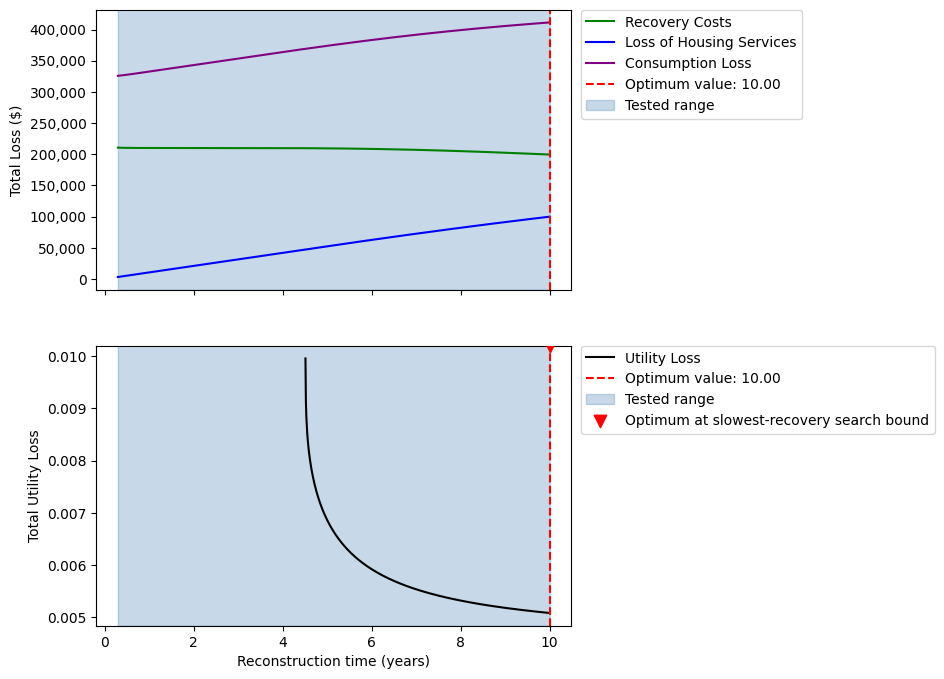

In [76]:
res = household.opt_lambda()
# opt_lambda classifies its outcome via `res["status"]` (OptLambdaStatus):
# INTERIOR / FLAT / BOUNDARY_LOWER / BOUNDARY_UPPER / INFEASIBLE / FAILED.
# `res["message"]` carries a short explanation and an actionable hint
# whenever the result is non-trivial. For this config the optimum lands at
# the slowest end of the λ search range (BOUNDARY_LOWER) — the plot
# annotates the boundary with a red marker.
print(f"Status: {res['status']}")
print(f"Success: {res['success']}")
if res["message"]:
    print(f"Message: {res['message']}")
if res["success"]:
    household.plot_opt_lambda(x_type="time")

In [77]:
household.get_losses("trapezoid")

Recovery Costs                       199500.549657
Loss of Housing Services              99892.379278
Loss of Housing Services (Rental)     25369.493150
Labour Income Loss (Public)           66594.919519
Labour Income Loss (Private)          20017.640468
Labour Income Loss                    86612.559987
Consumption Loss                     411374.982072
Utility Loss                              0.005082
Wellbeing Loss                       114999.296165
Wellbeing Loss (Integral)            114999.296165
Wellbeing Loss (Liquidity Term)           0.000000
Asset Loss                           210000.000000
Equity Weighted Asset Loss            47664.669425
Socio-economic Resilience                 1.826098
dtype: float64

In [78]:
print(f"Recovery Time: {household.recovery_time:.2f} years")
print(
    f"Achieved recovery in {household.config.simulation.t_max} years: {household.achieved_recovery_percent():.2f} %"
)

Recovery Time: 10.00 years
Achieved recovery in 10.0 years: 95.98 %


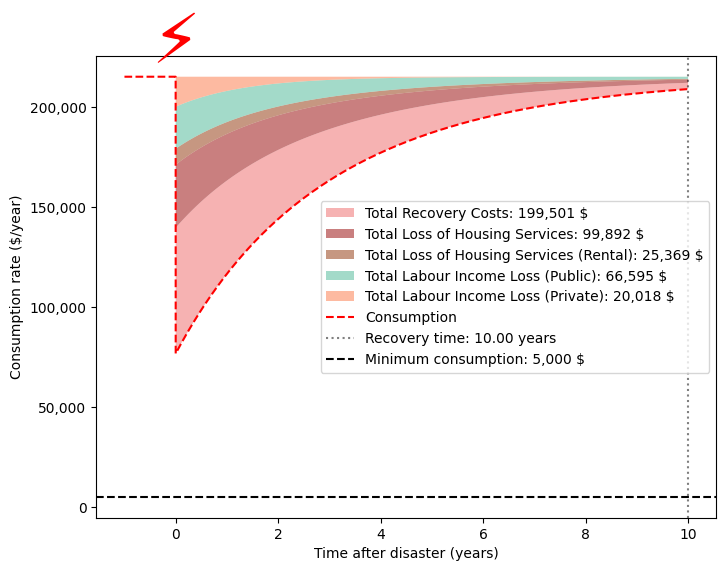

In [79]:
fig = household.plot_consumption()

## Sensitivity analysis

So far we looked at one configuration. Recovery dynamics depend on many knobs — damage severity, liquidity, diversified income, … — so let's sweep them and see how the **recovery times** change:

- **household τ** (`hh.recovery_time`) — the owner's reconstruction horizon.
- **composite τ** (`hh.composite_recovery_time()`) — the aggregate horizon across owner + rental + labour capital; slower components pull this up.
- **achieved recovery %** by `t_max` — how much of the asset stock has been rebuilt when the simulation ends.

The helper below builds a unit with a given (damage, diversified income, savings) triple and returns those metrics. Infeasible configurations return `NaN`s so the downstream plots show gaps instead of crashing.

In [80]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def sensitivity_run(v=0.7, i_div=20000, savings=0):
    """Build a CommunityUnit with the given knobs, optimise, and return
    recovery-time metrics. Rental / labour structure stays fixed at the
    notebook's baseline values; only owner damage (v), diversified
    income (i_div), and savings vary.

    Returns a dict with NaN values when the configuration is
    infeasible (no feasible λ in the search range).
    """
    cfg = WellBeingConfig(
        owner_housing=CapitalStock(v=v, k=300000, pi=0.15),
        rental_housing=IncomeStream(v=0.4, income=20000, recovery_time=10),
        labour_assets={
            "Public": IncomeStream(v=0.3, income=70000, recovery_time=10),
            "Private": IncomeStream(v=0.25, income=60000, recovery_time=4),
        },
        income=IncomeConfig(i_avg=80000, i_div=i_div),
        simulation=SimulationConfig(
            eta=1.5,
            rho=0.06,
            t_max=10,
            dt=1 / 52,
            currency="$",
            c_min=5000,
            recovery_per=95.0,
        ),
        liquidity=Liquidity(savings=savings),
    )
    hh = CommunityUnit(cfg)
    opt = hh.opt_lambda(raise_on_fail=False)
    if not opt["success"]:
        return {
            "household_tau": np.nan,
            "composite_tau": np.nan,
            "achieved_tmax": np.nan,
            "wellbeing_loss": np.nan,
            "per_component": None,
            "status": str(opt["status"]),
        }
    hh.get_losses("trapezoid")
    return {
        "household_tau": float(hh.recovery_time),
        "composite_tau": float(hh.composite_recovery_time() or np.nan),
        "achieved_tmax": float(hh.achieved_recovery_percent() or np.nan),
        "wellbeing_loss": float(hh.total_losses["Wellbeing Loss"]),
        "per_component": hh.recovery_time_per_component,
        "status": str(opt["status"]),
    }


### Effect of damage on recovery time

Varying the damage ratio `v` on owner housing (rental and labour held fixed). As `v` grows, the reconstruction burden grows too; at some point the feasibility constraint `c(t) ≥ c_min` bites and the optimiser can no longer find a viable λ — those rows return `NaN`.

,v,household_τ,composite_τ,achieved %,status
0,0.1,5.756043,8.401770,96.942065,interior
1,0.2,10.000000,8.913322,96.399273,boundary_lower
2,0.3,10.000000,9.011438,96.289765,boundary_lower
3,0.4,10.000000,9.093250,96.196153,boundary_lower
4,0.5,10.000000,9.162519,96.115210,boundary_lower
5,0.6,10.000000,9.221930,96.044528,boundary_lower
6,0.7,10.000000,9.273452,95.982271,boundary_lower
7,0.8,10.000000,9.318560,95.927018,boundary_lower
8,0.9,10.000000,9.358385,95.877651,boundary_lower


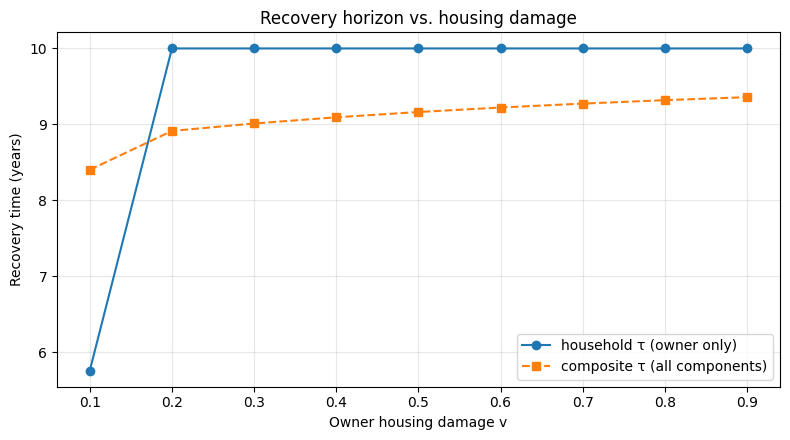

In [81]:
v_grid = np.round(np.linspace(0.1, 0.9, 9), 2)
rows = []
for v in v_grid:
    m = sensitivity_run(v=float(v))
    rows.append(
        {
            "v": v,
            "household_τ": m["household_tau"],
            "composite_τ": m["composite_tau"],
            "achieved %": m["achieved_tmax"],
            "status": m["status"],
        }
    )
df_v = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df_v["v"], df_v["household_τ"], marker="o", label="household τ (owner only)")
ax.plot(
    df_v["v"],
    df_v["composite_τ"],
    marker="s",
    linestyle="--",
    label="composite τ (all components)",
)
ax.set_xlabel("Owner housing damage v")
ax.set_ylabel("Recovery time (years)")
ax.set_title("Recovery horizon vs. housing damage")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
df_v

### Effect of liquidity on recovery

Savings, insurance, and external support smooth consumption through the recovery period. More liquidity → the household can tolerate higher reconstruction peaks → household τ tends to drop (faster recovery becomes feasible) and welfare loss shrinks.

,savings,household_τ,composite_τ,wellbeing_loss,status
0,0,10.000000,9.273452,114999.296165,boundary_lower
1,5000,10.000000,9.273452,112017.121829,boundary_lower
2,15000,10.000000,9.273452,107840.637099,boundary_lower
3,30000,10.000000,9.273452,103315.673693,boundary_lower
4,60000,10.000000,9.273452,97205.305812,boundary_lower
5,100000,4.991713,7.251370,90897.001435,interior
6,200000,0.300000,6.883414,73750.940297,boundary_upper


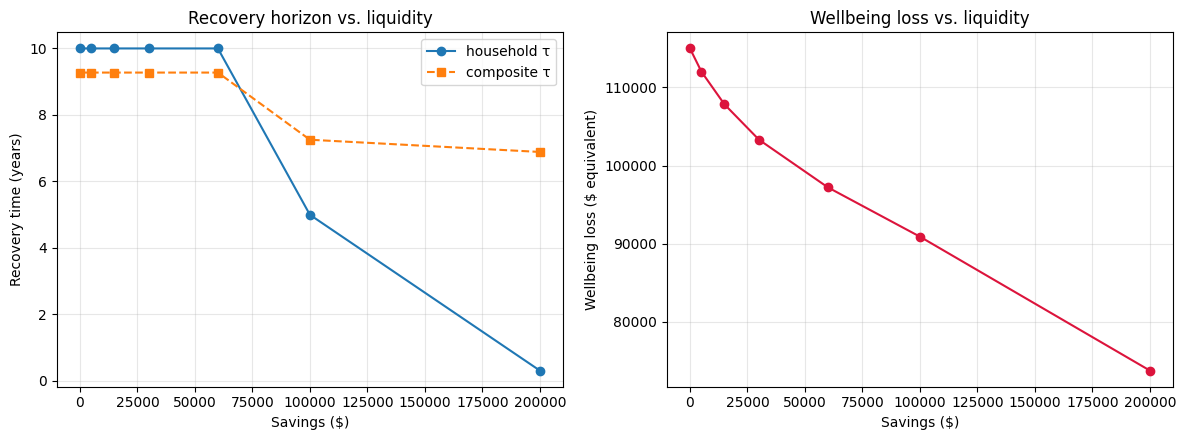

In [83]:
savings_grid = [0, 5_000, 15_000, 30_000, 60_000, 100_000, 200_000]
rows = []
for s in savings_grid:
    m = sensitivity_run(savings=float(s))
    rows.append(
        {
            "savings": s,
            "household_τ": m["household_tau"],
            "composite_τ": m["composite_tau"],
            "wellbeing_loss": m["wellbeing_loss"],
            "status": m["status"],
        }
    )
df_s = pd.DataFrame(rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(df_s["savings"], df_s["household_τ"], marker="o", label="household τ")
ax1.plot(
    df_s["savings"],
    df_s["composite_τ"],
    marker="s",
    linestyle="--",
    label="composite τ",
)
ax1.set_xlabel("Savings ($)")
ax1.set_ylabel("Recovery time (years)")
ax1.set_title("Recovery horizon vs. liquidity")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(df_s["savings"], df_s["wellbeing_loss"], marker="o", color="crimson")
ax2.set_xlabel("Savings ($)")
ax2.set_ylabel("Wellbeing loss ($ equivalent)")
ax2.set_title("Wellbeing loss vs. liquidity")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
df_s

### Effect of diversified income

`i_div` represents non-asset-based residual income (remittances, transfers, pensions). It raises the baseline `c0 = Σ π·k + i_div`, giving the household more headroom to absorb the peak consumption drop at `t=0` — so more aggressive recovery rates become feasible.

,i_div,household_τ,composite_τ,wellbeing_loss,status
0,5000,10.0,9.273452,133720.047106,boundary_lower
1,10000,10.0,9.273452,126904.811222,boundary_lower
2,20000,10.0,9.273452,114999.296165,boundary_lower
3,40000,10.0,9.273452,96338.215080,boundary_lower
4,80000,10.0,9.273452,71602.219403,boundary_lower


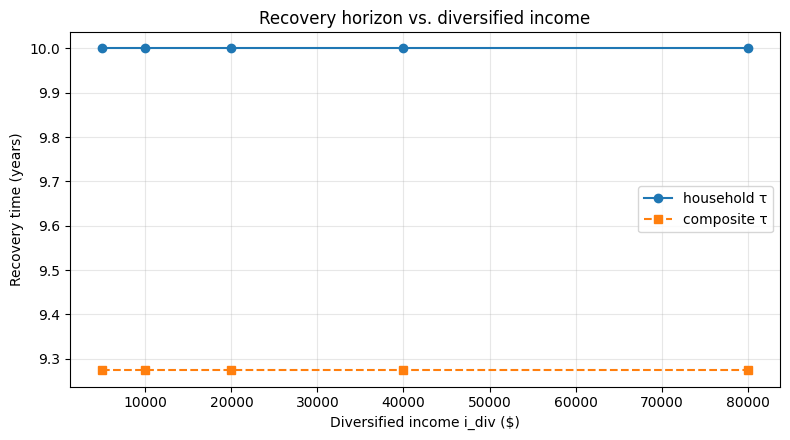

In [84]:
i_div_grid = [5_000, 10_000, 20_000, 40_000, 80_000]
rows = []
for i in i_div_grid:
    m = sensitivity_run(i_div=float(i))
    rows.append(
        {
            "i_div": i,
            "household_τ": m["household_tau"],
            "composite_τ": m["composite_tau"],
            "wellbeing_loss": m["wellbeing_loss"],
            "status": m["status"],
        }
    )
df_i = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df_i["i_div"], df_i["household_τ"], marker="o", label="household τ")
ax.plot(
    df_i["i_div"], df_i["composite_τ"], marker="s", linestyle="--", label="composite τ"
)
ax.set_xlabel("Diversified income i_div ($)")
ax.set_ylabel("Recovery time (years)")
ax.set_title("Recovery horizon vs. diversified income")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
df_i

### Joint damage × liquidity heatmap

A 2-D grid shows how the two knobs interact. The left panel is the household-only τ (owner reconstruction horizon); the right panel is the composite τ across owner + rental + labour. Blank cells are infeasible configurations where no λ in the default search range keeps `c(t) ≥ c_min`.

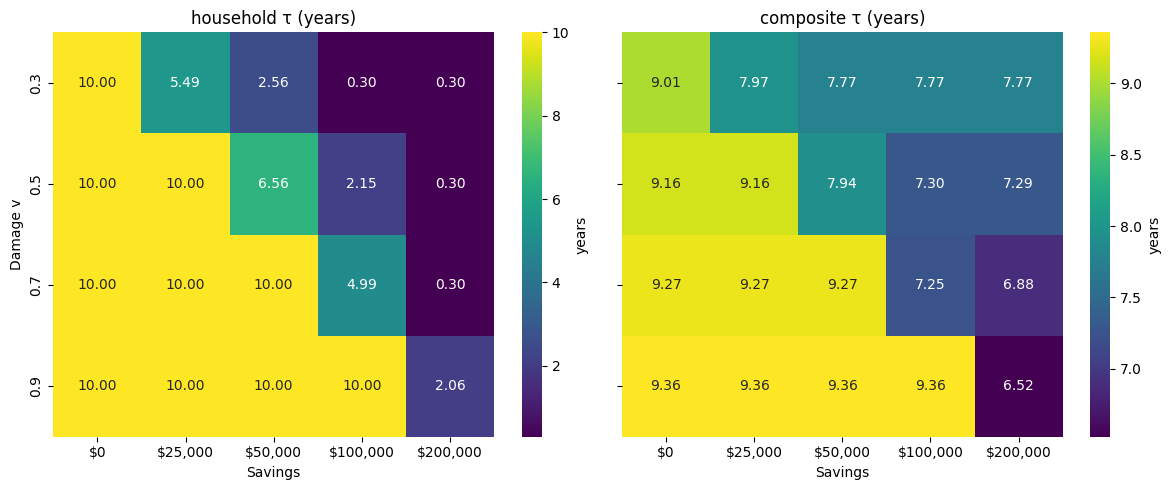

In [85]:
v_axis = [0.3, 0.5, 0.7, 0.9]
s_axis = [0, 25_000, 50_000, 100_000, 200_000]

hh_mat = np.full((len(v_axis), len(s_axis)), np.nan)
co_mat = np.full((len(v_axis), len(s_axis)), np.nan)
for i, v in enumerate(v_axis):
    for j, s in enumerate(s_axis):
        m = sensitivity_run(v=float(v), savings=float(s))
        hh_mat[i, j] = m["household_tau"]
        co_mat[i, j] = m["composite_tau"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, data, title in [
    (ax1, hh_mat, "household τ (years)"),
    (ax2, co_mat, "composite τ (years)"),
]:
    sns.heatmap(
        data,
        xticklabels=[f"${s:,.0f}" for s in s_axis],
        yticklabels=[f"{v:.1f}" for v in v_axis],
        annot=True,
        fmt=".2f",
        cmap="viridis",
        ax=ax,
        cbar_kws={"label": "years"},
    )
    ax.set_xlabel("Savings")
    ax.set_title(title)
ax1.set_ylabel("Damage v")
plt.tight_layout()